In [52]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
from  sklearn.cluster import KMeans
from yellowbrick.cluster import silhouette_visualizer
from sklearn.preprocessing import StandardScaler

# A telecom company wants to segment its customer base to provide personalized services and offers. The goal is to group similar customers together based on their usage behavior, demographics, and preferences using clustering techniques. This segmentation will help the company better target marketing campaigns, reduce churn, and improve customer satisfaction.

# Do Data pre-processing 

In [54]:
telecom = pd.read_csv("telecom_customer_segmentation.csv")

In [55]:
telecom[telecom.duplicated()]

,Region,Gender,SubscriptionType,InternetUsageType,CustomerSupportCalls,ContractType,MonthlyCharges,TotalCharges,CallMinutesPerMonth,InternetGBPerMonth,NumberOfSMSPerMonth,TenureMonths,Age


In [56]:
telecom.isnull().sum()

Region                  0
Gender                  0
SubscriptionType        0
InternetUsageType       0
CustomerSupportCalls    0
ContractType            0
MonthlyCharges          0
TotalCharges            0
CallMinutesPerMonth     0
InternetGBPerMonth      0
NumberOfSMSPerMonth     0
TenureMonths            0
Age                     0
dtype: int64

In [57]:
cat= telecom.select_dtypes(include="object").columns

In [58]:
cat

Index(['Region', 'Gender', 'SubscriptionType', 'InternetUsageType',
       'CustomerSupportCalls', 'ContractType'],
      dtype='object')

In [59]:
for i in cat:
    print(telecom[i].unique())

['West' 'Central' 'East' 'South' 'North-East' 'North']
['Other' 'Male' 'Female']
['Postpaid' 'Prepaid']
['Light' 'Heavy' 'Moderate']
['High' 'Medium' 'Low']
['Monthly' 'Quarterly' 'Yearly']


In [60]:
telecom["CustomerSupportCalls"].unique()

array(['High', 'Medium', 'Low'], dtype=object)

In [61]:
telecom["CustomerSupportCalls"]=telecom["CustomerSupportCalls"].apply(lambda x: 
                                                                      3 if x=='High' 
                                                                      else 2 if x=='Medium' 
                                                                      else 1)

In [62]:
telecom["CustomerSupportCalls"].unique()

array([3, 2, 1], dtype=int64)

In [63]:
telecom["SubscriptionType"].unique()

array(['Postpaid', 'Prepaid'], dtype=object)

In [64]:
telecom["SubscriptionType"]=telecom["SubscriptionType"].apply(lambda x:  1 if x=='Postpaid' else 0) 
                                                                      
                                                                

In [65]:
telecom["SubscriptionType"].unique()

array([1, 0], dtype=int64)

In [66]:
telecom["InternetUsageType"].unique()

array(['Light', 'Heavy', 'Moderate'], dtype=object)

In [67]:
telecom["InternetUsageType"]=telecom["InternetUsageType"].apply(lambda x:3 if x=='Heavy'
                                                               else 2 if x=='Moderate'
                                                               else 1)

In [68]:
telecom["InternetUsageType"].unique()

array([1, 3, 2], dtype=int64)

In [69]:
telecom["ContractType"].unique()

array(['Monthly', 'Quarterly', 'Yearly'], dtype=object)

In [70]:
pd.get_dummies(telecom["ContractType"]).astype("int64") ### to encode ContractType

,Monthly,Quarterly,Yearly
0,1,0,0
1,0,1,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
99995,1,0,0
99996,0,1,0
99997,0,1,0
99998,0,0,1


In [71]:
telecom= pd.concat([pd.get_dummies(telecom["ContractType"]).astype("int64"),telecom],axis=1)

In [72]:
telecom.drop("ContractType",axis=1,inplace=True)

In [73]:
telecom

,Monthly,Quarterly,Yearly,Region,Gender,SubscriptionType,InternetUsageType,CustomerSupportCalls,MonthlyCharges,TotalCharges,CallMinutesPerMonth,InternetGBPerMonth,NumberOfSMSPerMonth,TenureMonths,Age
0,1,0,0,West,Other,1,1,3,28.06,718.32,537.64,23.55,58.0,23,74
1,0,1,0,Central,Male,1,3,3,42.99,1164.18,565.91,29.16,69.0,3,23
2,0,1,0,East,Male,0,1,2,60.06,1165.59,692.74,32.57,94.0,6,66
3,1,0,0,Central,Female,0,1,2,31.96,542.34,564.78,24.59,114.0,16,74
4,1,0,0,Central,Male,1,2,2,56.74,751.81,592.89,52.61,81.0,7,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0,0,North-East,Female,1,2,3,67.14,1080.51,566.05,33.51,53.0,26,54
99996,0,1,0,Central,Female,1,2,3,79.36,776.31,640.90,24.73,110.0,51,27
99997,0,1,0,West,Female,0,2,1,61.02,1003.09,536.94,35.89,79.0,36,48
99998,0,0,1,North,Male,1,2,3,31.73,1095.84,617.08,30.14,134.0,45,79


In [74]:
pd.set_option("display.max_columns",None)

In [75]:

telecom= pd.concat([pd.get_dummies(telecom["Gender"]).astype("int64"),telecom],axis=1)
telecom.drop("Gender",axis=1,inplace=True)

In [76]:

telecom= pd.concat([pd.get_dummies(telecom["Region"]).astype("int64"),telecom],axis=1)
telecom.drop("Region",axis=1,inplace=True)

In [77]:
telecom

,Central,East,North,North-East,South,West,Female,Male,Other,Monthly,Quarterly,Yearly,SubscriptionType,InternetUsageType,CustomerSupportCalls,MonthlyCharges,TotalCharges,CallMinutesPerMonth,InternetGBPerMonth,NumberOfSMSPerMonth,TenureMonths,Age
0,0,0,0,0,0,1,0,0,1,1,0,0,1,1,3,28.06,718.32,537.64,23.55,58.0,23,74
1,1,0,0,0,0,0,0,1,0,0,1,0,1,3,3,42.99,1164.18,565.91,29.16,69.0,3,23
2,0,1,0,0,0,0,0,1,0,0,1,0,0,1,2,60.06,1165.59,692.74,32.57,94.0,6,66
3,1,0,0,0,0,0,1,0,0,1,0,0,0,1,2,31.96,542.34,564.78,24.59,114.0,16,74
4,1,0,0,0,0,0,0,1,0,1,0,0,1,2,2,56.74,751.81,592.89,52.61,81.0,7,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,0,0,1,0,0,1,0,0,1,0,0,1,2,3,67.14,1080.51,566.05,33.51,53.0,26,54
99996,1,0,0,0,0,0,1,0,0,0,1,0,1,2,3,79.36,776.31,640.90,24.73,110.0,51,27
99997,0,0,0,0,0,1,1,0,0,0,1,0,0,2,1,61.02,1003.09,536.94,35.89,79.0,36,48
99998,0,0,1,0,0,0,0,1,0,0,0,1,1,2,3,31.73,1095.84,617.08,30.14,134.0,45,79


In [78]:
## Standardize the data 

In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
s = StandardScaler()

In [81]:
for i in telecom.columns:
    telecom[i]=s.fit_transform(telecom[[i]])

In [82]:
wcss=[]

In [83]:
for i in range(2,7):
    k = KMeans(n_clusters=i,random_state=24)
    k.fit(telecom)
    wcss.append(k.inertia_)
    

In [84]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'WCSS')

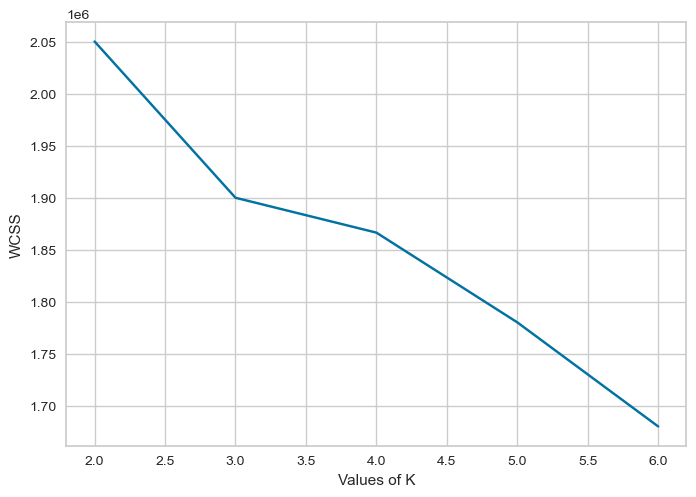

In [85]:
plt.plot(range(2,7),wcss)
plt.xlabel("Values of K")
plt.ylabel("WCSS")


In [86]:
sample = telecom.sample(10000)

c:\Users\Sahib Chouhan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


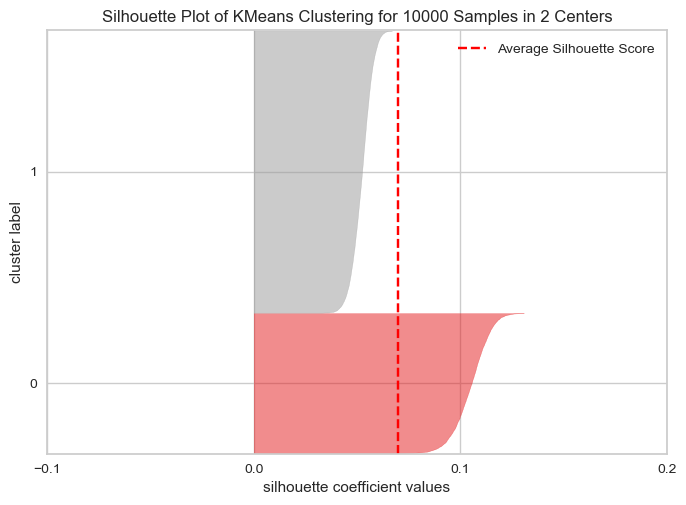

c:\Users\Sahib Chouhan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


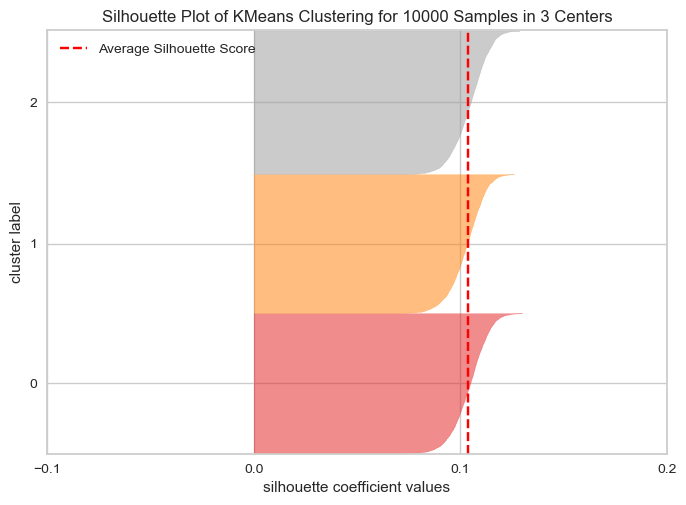

c:\Users\Sahib Chouhan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


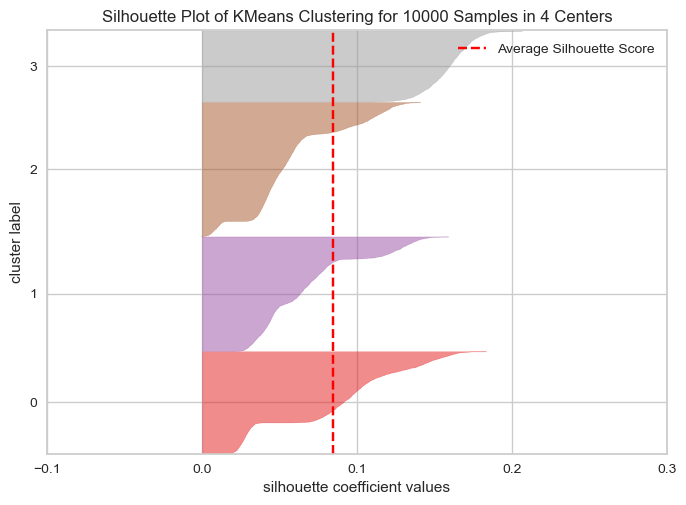

c:\Users\Sahib Chouhan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


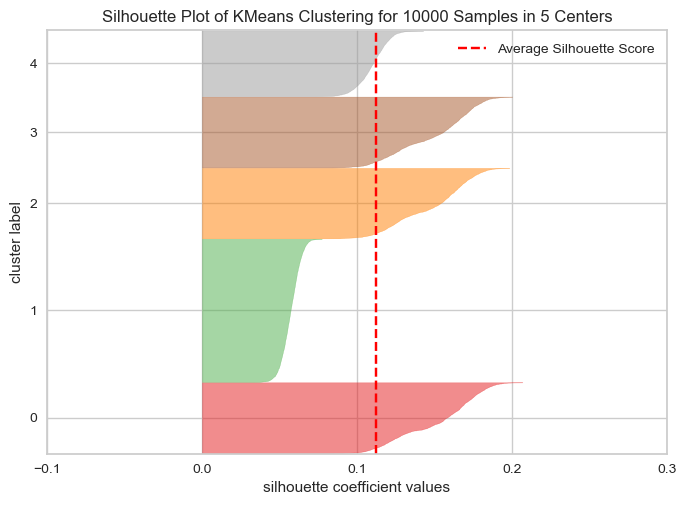

c:\Users\Sahib Chouhan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


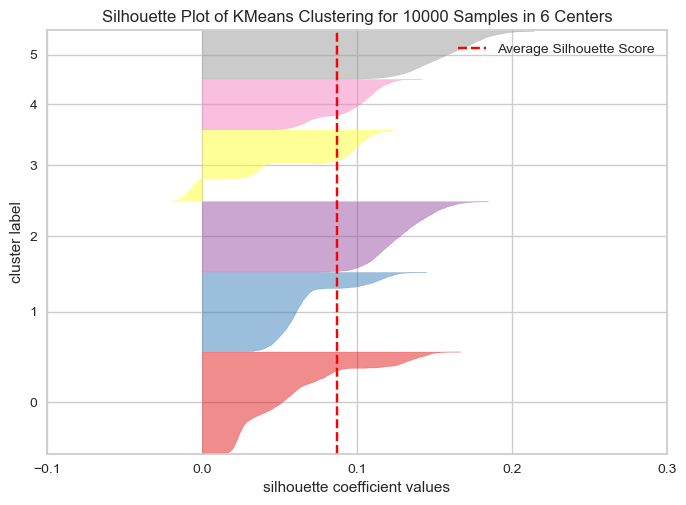

In [87]:
for i in range(2,7):
    k = KMeans(n_clusters=i,random_state=24)
    k.fit(sample)
    silhouette_visualizer(k,sample)
    

# k= 6 AS OPTIMAL VALUES OF CLUSTERS 

In [88]:
from sklearn.cluster import AgglomerativeClustering,DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

In [89]:
z =linkage(sample)

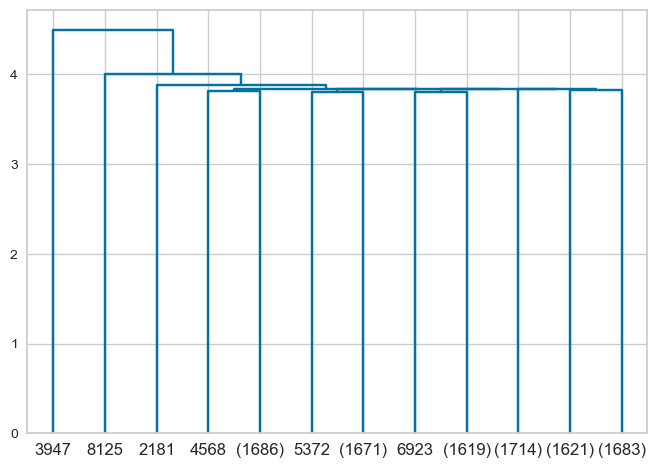

In [104]:
dendrogram(z,truncate_mode='lastp',p=12)
plt.show()

In [91]:
ag =AgglomerativeClustering(n_clusters=6)

In [92]:
ag.fit(sample)

AgglomerativeClustering(n_clusters=6)

In [93]:
ag.labels_ ## no.of classess i.e. six 

array([2, 2, 4, ..., 0, 2, 4], dtype=int64)

In [94]:
sample = pd.concat([sample,pd.DataFrame
                    (ag.labels_,columns=['Class'])],axis=1)

In [95]:
import seaborn as sns

<Axes: xlabel='TotalCharges', ylabel='CallMinutesPerMonth'>

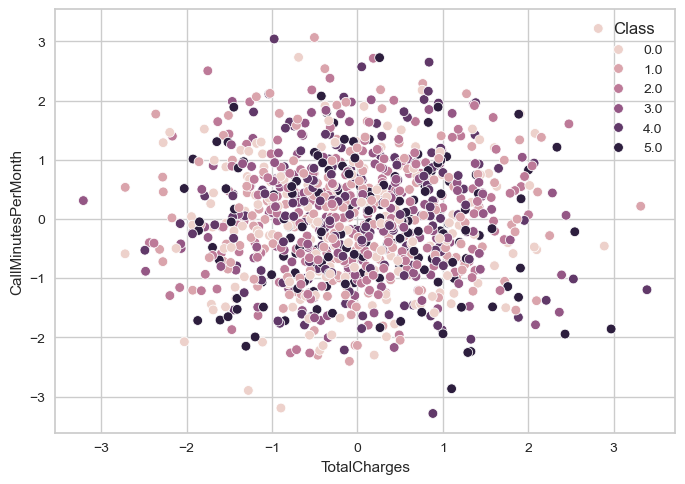

In [96]:
sns.scatterplot(x= sample["TotalCharges"],y= sample["CallMinutesPerMonth"]
               ,hue=sample["Class"]) ##Not able to get info 

In [97]:
db = DBSCAN(eps=0.3,min_samples=6)

In [98]:
sample2 = telecom.sample(10000,random_state=24)

In [99]:
sample.dropna(inplace=True)

In [100]:
db.fit(np.array(sample2
               ))

DBSCAN(eps=0.3, min_samples=6)

In [101]:
db.labels_

array([-1, -1, -1, ..., -1, -1, -1], dtype=int64)